# Exploring Inter-Research Infrastructure connection (Part 1): ARGO and CMEMS
Earthquake - Tsunami - Ocean Properties - Biogeochemical


#### ===========================================================================================

### Study Case

**Investigate the impact of tsunamis on physical and biochemical properties of seawater, using ARGO data (ARGO-BGC) and CMEMS data, specifically focusing on the Ionian Sea earthquakes on** 
Study Cases:
- October 25, 2016: Magnitude 6.6 earthquake in the Ionian Sea.
- October 26, 2016: Magnitude 6.4 earthquake in the Ionian Sea.
- October 26, 2018: Magnitude 6.8 earthquake in the Ionian Sea.

**Specific Objective:** To investigate the coincidence of having BGC-Argo floats during tsunami events and to analyze the physical and biochemical changes in water properties, at the same time investigating the surface water height to visualise the ocean wave.

**Research Infrastructure:** 
ARGO - CMEMS

**You will learn:** (1-) You will learn how to retrieve "In-situ" data using ERDDAP* by the ARGO platform through IFREMER. (2-) how to download Satellite product and Reanalyses data using OpenDAP* through CMEMS platform 

#### ===========================================================================================


### CMEMS:
**Data Collection:** Extract CMEMS data from OpenDAP, and select variables of the study interest

**Variable chosen:** Sea Level Anomalies (SLA), to investigate different height of seas surface height.

**Expected Physical Changes:** You are expected to visualise an exceptional change of the SLA [meter] showing effects of the Tsunami.

### ARGO:
**Data Collection:** Retrieve BGC-Argo float data for the specified tsunami events using the provided URLs.
Extract relevant variables such as bbp700 (Backscattering at 700 nm beam), chla (chlorophyll), pres (pressure), latitude, longitude, direction, platform number, cycle number, and time.

**Data Processing:**
Create dictionaries to organize profile variables by platform number.
Convert cycle numbers to profiles and equalize array shapes for unhomogeneous data.

**Analysis:**
Compare physical and biochemical properties of seawater before, during, and after the tsunami events.
Identify significant changes in water properties and primary production.
(Optional) Evaluate the potential impact on fish populations based on changes in primary productivity.

**Expected Physical Changes**: Identification of significant disturbances in water properties such as temperature, salinity, and turbidity following tsunami events.

**Expected Biogeochemical Processes**: Evidence of enhanced primary production, indicated by increased chlorophyll concentrations and other biochemical markers.


#### ===========================================================================================
# CMEMS DATA

In [33]:
# ===========================================================================================
# --- Prerequisite Installation Steps (Confirmed Working for macOS M1/M2) -------------------


# First, you need to register to CMEMS platform (https://data.marine.copernicus.eu/register) in order to get your personal Username and Password


# These steps were successfully used to set up the environment and install packages:
# 1. Create a new Conda environment (OPTIONAL but highly recommended for isolation):
#    conda create -n cmems_data_env python=3.9
#
# 2. Activate the new environment: (If you have a conda activated, start with "conda deactivate"*)
#    conda activate cmems_data_env
#
# 3. Install Mamba (for faster and more reliable dependency resolution, especially with conda-forge):
#    conda install -c conda-forge mamba
#
# 4. Install core packages using Mamba, prioritizing conda-forge:
#    mamba install -c conda-forge numpy xarray matplotlib pandas ipython
#
# 5. Install the copernicusmarine toolbox:
#    mamba install -c conda-forge copernicusmarine
#
# 6. Verify installations (optional, but recommended):
#    conda list | grep "numpy"
#    conda list | grep "xarray"
#    conda list | grep "copernicusmarine"
#    (Check for expected versions like numpy 1.24.4, xarray 2024.7.0, copernicusmarine 2.1.2 from conda-forge)
#
# 7. Set your Copernicus Marine credentials as environment variables (HIGHLY RECOMMENDED for security):
#    export COPERNICUSMARINE_SERVICE_USERNAME="<your_username>"
#    export COPERNICUSMARINE_SERVICE_PASSWORD="<your_password>"
#    (Replace 'your_actual_password_here' with your real password)
#    (Add these lines to your ~/.bashrc, ~/.zshrc, or ~/.bash_profile for persistence)
#
# 8. Alternatively, you can use a credentials file as explained in Copernicus Marine docs:
#    copernicusmarine login --username your_username --password your_password
#
# ===========================================================================================

In [35]:
!pip install --quiet --upgrade numpy pandas matplotlib tqdm obspy cdsapi xarray netCDF4 cfgrib cartopy shapely pyproj descartes rasterio pillow 

# Primary packages for the first study case
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import copernicusmarine
import xarray as xr
import pandas as pd 
import os


In [2]:
# Packages dedicated for the second study case
import matplotlib.pyplot as plt
from glob import glob
from pylab import *
import requests
import pickle
import json
  

**Exceptional case:** 
- October 25, 2016: Magnitude 6.6 earthquake in the Ionian Sea.
- October 26, 2016: Magnitude 6.4 earthquake in the Ionian Sea.
- October 26, 2018: Magnitude 6.8 earthquake in the Ionian Sea.

In [34]:
original_tsunami_events = [
    {"date": "2016-10-25", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"},
    {"date": "2016-10-26", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"},
    {"date": "2018-10-26", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"}, # Choosen
]

In [4]:
# ===========================================================================================
# CMEMS credentials — NEVER hard-code a password in a notebook you intend to share.
# Recommended: run `copernicusmarine login` once (stores an encrypted credentials file),
# then leave USERNAME / PASSWORD blank below. Alternatively, export them before launching
# Jupyter:
#     export COPERNICUSMARINE_SERVICE_USERNAME="<your_username>"
#     export COPERNICUSMARINE_SERVICE_PASSWORD="<your_password>"
# Register for free at https://data.marine.copernicus.eu/register

USERNAME = os.environ.get("COPERNICUSMARINE_SERVICE_USERNAME", "")   # blank -> use `copernicusmarine login` cache
PASSWORD = os.environ.get("COPERNICUSMARINE_SERVICE_PASSWORD", "")

DATASET_ID = "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D"


In [5]:
# ===========================================================================================
# Geographical area and temporal coverage (This must be align with the "original_tsunami_events")
start_date_str = "2018-10-25T12:00:00Z"
end_date_str = "2018-10-28T13:00:00Z" # Fetching multiple days of data


# Geographical area (define the locations based on "original_tsunami_events")
extent = 5
min_latitude = 35 - extent
max_latitude = 45 + extent
min_longitude = 15 - extent
max_longitude = 30 + extent



In [6]:

# ===========================================================================================
# Variables to download: For this dataset, 'sla' (Sea Level Anomaly) is the relevant variable.

variables_of_interest = ["sla"] # Sea Level Anomaly

# ===========================================================================================
# Determine if the data range is daily or spans multiple days/months
# This is built to to define the temporal resolution and for naming the dowloaded files

start_date_obj_for_filename = pd.to_datetime(start_date_str)
end_date_obj_for_filename = pd.to_datetime(end_date_str)

# Calculate the difference in days
time_delta_days = (end_date_obj_for_filename - start_date_obj_for_filename).days

# Base filename part from variables
var_name_for_filename = "_".join(variables_of_interest)

# Construct the date part of the filename
if time_delta_days < 2: # If less than 2 full days, consider it "daily" based on start date
    date_part = start_date_obj_for_filename.strftime("%Y%m%d") # YYYYMMDD for a single day
    time_frequency_tag = "daily"
elif time_delta_days <= 31: # If up to about a month, use start and end day
    date_part = f"{start_date_obj_for_filename.strftime('%Y%m%d')}_to_{end_date_obj_for_filename.strftime('%Y%m%d')}"
    time_frequency_tag = "multiday"
else: # For longer periods, consider it "monthly" or a date range
    date_part = f"{start_date_obj_for_filename.strftime('%Y%m')}_to_{end_date_obj_for_filename.strftime('%Y%m')}" # YYYYMM_to_YYYYMM
    time_frequency_tag = "monthly"

# ===========================================================================================
# Combine parts to form the output filename
output_filename = f"{var_name_for_filename}_{date_part}_{time_frequency_tag}_subset.nc"

output_directory = "./cmems_data" # Create a directory to store downloaded data

# Create the output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# ===========================================================================================
# Printing for checking outputs
print(f"Attempting to download data for Dataset ID: {DATASET_ID}")
print(f"Time range (UTC): {start_date_str} to {end_date_str}")
print(f"Lat/Lon box: {min_latitude}-{max_latitude} N, {min_longitude}-{max_longitude} E")
print(f"Variables: {variables_of_interest}")



Attempting to download data for Dataset ID: cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D
Time range (UTC): 2018-10-25T12:00:00Z to 2018-10-28T13:00:00Z
Lat/Lon box: 30-50 N, 10-35 E
Variables: ['sla']


In [7]:
# ===========================================================================================
# Execute the spatial and temporal subset using copernicusmarine
# passing through your username and password
# And download the output file as NetCDF File

try:
    # Use the subset function from copernicusmarine, passing credentials directly
    copernicusmarine.subset(
        dataset_id=DATASET_ID,
        variables=variables_of_interest,
        minimum_longitude=min_longitude,
        maximum_longitude=max_longitude,
        minimum_latitude=min_latitude,
        maximum_latitude=max_latitude,
        start_datetime=start_date_str,
        end_datetime=end_date_str,
        output_directory=output_directory,
        output_filename=output_filename,
        username=USERNAME or None,  # blank -> falls back to `copernicusmarine login` cache
        password=PASSWORD or None,
    )                               # NB: force_download was removed in copernicusmarine v2 (Jan 2025)
    # New folder created and store the NetCDF File
    print(f"Data successfully downloaded to {os.path.join(output_directory, output_filename)}")

    # ===========================================================================================
    # ===========================================================================================
    # Open the downloaded NetCDF file with xarray
    file_path = os.path.join(output_directory, output_filename)
    ds = xr.open_dataset(file_path)

    # Convert the string date to a pandas Timestamp, then make it timezone-naive
    # to match the likely timezone-naive 'time' coordinate in the downloaded dataset.
    target_time = pd.to_datetime(start_date_str).tz_localize(None)

    # Select the Sea Level Anomaly field (sla) for the target time
    # 'method="nearest"' will select the closest available time if an exact match isn't present.
    sea_level_anomaly = ds['sla'].sel(time=target_time, method="nearest") # Sea level height

    # Display the selected data
    print("\nDownloaded Sea Level Anomaly data:")

# ===========================================================================================
# In case the channel is not responding - General exception handling with custom messages based on common errors

except Exception as e:
    print(f"An error occurred: {e}")
    error_message = str(e) # Convert exception to string for checking keywords

    if "Authentication" in error_message or "credentials" in error_message or "InvalidUsernameOrPassword" in error_message:
        print("This might be an authentication issue. Check your COPERNICUSMARINE_SERVICE_USERNAME and COPERNICUSMARINE_SERVICE_PASSWORD environment variables or run the copernicusmarine login command.")
        print("Ensure you have accepted the Terms & Conditions on the Copernicus Marine website.")
    elif "CoordinatesOutOfDatasetBounds" in error_message or "time dimension exceed the dataset coordinates" in error_message:
        print("Data request out of bounds. Please adjust the time and/or spatial coordinates to be within the dataset's available range.")
        print(f"The requested time range was: {start_date_str} to {end_date_str}")
        print("Check the dataset's available date range on the Copernicus Marine website product page.")
    elif "DatasetNotFound" in error_message:
        print(f"Dataset ID '{DATASET_ID}' not found. Please verify the dataset ID on the Copernicus Marine website.")
    elif "VariableDoesNotExistInTheDataset" in error_message:
        print(f"Variable '{variables_of_interest}' not found in dataset. Please verify variable names on the Copernicus Marine website product page.")
    else:
        print("This is a general error. Review the traceback for more details and consider consulting the Copernicus Marine Toolbox documentation or support.")




WARNING - 2025-06-24T13:12:08Z - 'force_download' has been deprecated.
INFO - 2025-06-24T13:12:11Z - Selected dataset version: "202411"
INFO - 2025-06-24T13:12:11Z - Selected dataset part: "default"
INFO - 2025-06-24T13:12:16Z - Starting download. Please wait...
100%|███████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  4.17it/s]
INFO - 2025-06-24T13:12:19Z - Successfully downloaded to cmems_data/sla_20181025_to_20181028_multiday_subset.nc


Data successfully downloaded to ./cmems_data/sla_20181025_to_20181028_multiday_subset.nc

Downloaded Sea Level Anomaly data:


In [8]:

# Open the downloaded NetCDF file with xarray
output_directory = "./cmems_data" # Create a directory to store downloaded data
file_path = os.path.join(output_directory, "sla_20181025_to_20181028_multiday_subset.nc")
ds = xr.open_dataset(file_path)



In [9]:
ds

<xarray.Dataset> Size: 769kB
Dimensions:    (time: 3, latitude: 160, longitude: 200)
Coordinates:
  * latitude   (latitude) float32 640B 30.06 30.19 30.31 ... 49.69 49.81 49.94
  * longitude  (longitude) float32 800B 10.06 10.19 10.31 ... 34.69 34.81 34.94
  * time       (time) datetime64[ns] 24B 2018-10-26 2018-10-27 2018-10-28
Data variables:
    sla        (time, latitude, longitude) float64 768kB ...
Attributes:
    source:                    Altimetry measurements
    references:                http://marine.copernicus.eu
    institution:               CLS, CNES
    history:                   2024-10-23 12:55:06Z: Creation
    Conventions:               CF-1.6
    title:                     DT merged all satellites Global Ocean Gridded ...
    comment:                   Sea Surface Height measured by Altimetry and d...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    copernicusmarine_version:  2.1.2

In [10]:

# Convert the string date to a pandas Timestamp, then make it timezone-naive
# to match the likely timezone-naive 'time' coordinate in the downloaded dataset.
target_time = pd.to_datetime(start_date_str).tz_localize(None)

# Select the Sea Level Anomaly field (sla) for the target time
# 'method="nearest"' will select the closest available time if an exact match isn't present.
lat = ds['latitude']
lon = ds['longitude']

sea_level_anomaly = ds['sla'].sel(time=target_time, method="nearest")


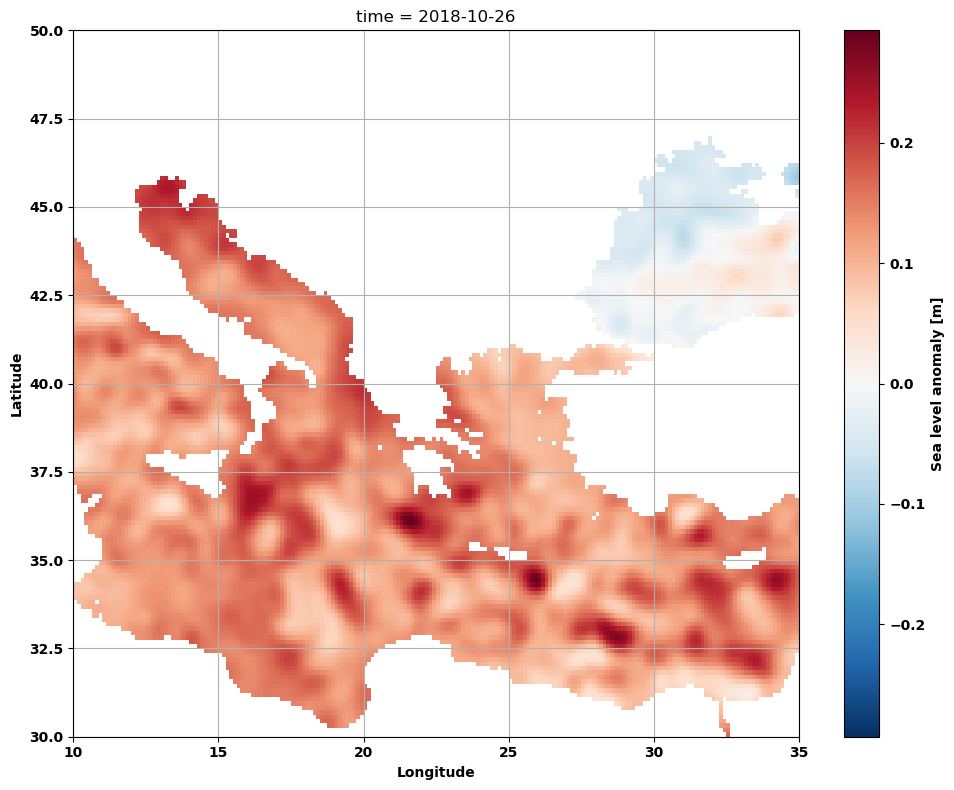

In [38]:
# Plotting the data - View the surface of the water (anomaly height)

plt.figure(figsize=(10, 8))
sea_level_anomaly.plot()
# Format the title to show the actual time selected by xarray (could be slightly different due to 'nearest')
# plt.title(f"Sea Level Anomaly for {sea_level_anomaly['time'].item().isoformat(timespec='minutes')} (subset from CMEMS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
#imshow(sea_level_anomaly[::-1]);colorbar()

#contourf(lon,lat,sea_level_anomaly,levels=np.linspace(-.33,.33,11),cmap="RdBu_r");colorbar()

#### ===========================================================================================
# ARGO BGC DATA
#### ===========================================================================================

In [17]:
# ===========================================================================================
# Important function for Requesting Variables from ERDDAP.IFREMER endpoints

def set_url(latitude_range, longitude_range, start_time, end_time):
    """
    Variables1: bbp700,bbp700_adjusted,chla,chla_adjusted,pres,pres_adjusted,
    Variables2: latitude,longitude,direction,platform_number,cycle_number.
    latitude[min,max] - longitude[min,max]
    """ 
    base_url = "https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats-synthetic-BGC.json"
    selected_variables = "bbp700,bbp700_adjusted,chla,chla_adjusted,pres,pres_adjusted,latitude,longitude,direction,platform_number,cycle_number,time"
    latitude_constraint = f"latitude>={latitude_range[0]}&latitude<={latitude_range[1]}"
    longitude_constraint = f"longitude>={longitude_range[0]}&longitude<={longitude_range[1]}"
    time_constraint = f"time>={start_time}&time<={end_time}"
    return f"{base_url}?{selected_variables}&{latitude_constraint}&{longitude_constraint}&{time_constraint}"




In [18]:

# ===========================================================================================
# Functions identify "cycles" (when the float goes up and down)

def create_dict_profile_variable(platform_number, variable):
    # Get indices from common platform_number
    argoid, indices = np.unique(platform_number, return_index=True)
    result = {}
    for i, val, start_idx in zip(range(len(argoid)), argoid, indices):
        indicei = np.append(indices,len(platform_number))
        end_idx = indicei[i + 1]
        variable = [np.nan if value is None else value for value in variable]
        result[str(val)] = variable[start_idx:end_idx]
    return result


def cycle_number_to_profile(data,profile):
    cycle_number = {}
    for i, value in enumerate(profile):
        # Check if the value exists as a key in the dictionary
        if str(value) in cycle_number:
            # Append the corresponding data value to the list for that profile value
            cycle_number[str(value)].append(data[i])
        else:
            # Create a new list for the profile value if it doesn't exist in the dictionary
            cycle_number[str(value)] = [data[i]]
    return cycle_number


# ===========================================================================================
# Auxiliary functions (Optional)

def write_pkl(fnameout,data):
    fnout=open(fnameout,'wb')
    return pickle.dump(data,fnout)


def fitting_array(variable,max_length):
    """
    Function: Equalize unhomogeneous array shape from multiple Argo profile.
    - Missing parts are replaced with NaNs
    - Options: (1) Set constant max_length (if), or (2) max_length will be computed (else).
    """

    if max_length is not None:
        max_length1=max_length
    else:
        max_length1=max([len(element) for element in variable])
    variablei=np.array([np.pad(profile,(0,max_length1-len(profile)),constant_values=np.nan) for profile in variable])

    return variablei
    
# ===========================================================================================
# Figures Functions 

def add_colorbar(mappable):
    '''
    Adding colorbar
    '''
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.pyplot as plt
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

def akw(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

def labely(ax,l='$f$'):
    from matplotlib.font_manager import FontProperties
    font0=FontProperties()
    font=font0.copy()
    font.set_weight('bold')
    ax.text(.1,1.,l,color='k',fontproperties=font,fontsize=12.,horizontalalignment='left',transform=ax.transAxes,bbox=dict(boxstyle='circle,pad=0.1',fc='.95',alpha=.9))


In [19]:
# ===========================================================================================
# Reproduced from above (for reminding)

from datetime import datetime, timedelta

original_tsunami_events = [
    {"date": "2016-10-25", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"}, # 0
    {"date": "2016-10-26", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"}, # 1
    {"date": "2018-10-26", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"}, # 2
]


# Adjust the latitude and longitude by adding two degrees on each side to detect the presence of potential float
adjusted_tsunami_events = []
for event in original_tsunami_events:
    adjusted_event = {
        "date": event["date"],
        "latitude": (event["latitude"][0] - 2, event["latitude"][1] + 2),
        "longitude": (event["longitude"][0] - 2, event["longitude"][1] + 2),
        "place": event["place"]
    }
    adjusted_tsunami_events.append(adjusted_event)


# Loop through the tsunami events and construct URLs
urls = []
for event in adjusted_tsunami_events:
    latitude = event["latitude"]
    longitude = event["longitude"]
    start_date = datetime.strptime(event['date'], "%Y-%m-%d") - timedelta(days=7)
    end_date = datetime.strptime(event['date'], "%Y-%m-%d") + timedelta(days=7)
    start_time = start_date.strftime("%Y-%m-%dT%H:%M:%SZ")
    end_time = end_date.strftime("%Y-%m-%dT%H:%M:%SZ")
    
    # Construct the URL
    url0 = set_url(latitude, longitude, start_time, end_time)
    urls.append(url0)



In [20]:
# Printed the final "url" containing all variables set above

print(urls)

['https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats-synthetic-BGC.json?bbp700,bbp700_adjusted,chla,chla_adjusted,pres,pres_adjusted,latitude,longitude,direction,platform_number,cycle_number,time&latitude>=35.0&latitude<=40.0&longitude>=18.0&longitude<=23.0&time>=2016-10-18T00:00:00Z&time<=2016-11-01T00:00:00Z', 'https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats-synthetic-BGC.json?bbp700,bbp700_adjusted,chla,chla_adjusted,pres,pres_adjusted,latitude,longitude,direction,platform_number,cycle_number,time&latitude>=35.0&latitude<=40.0&longitude>=18.0&longitude<=23.0&time>=2016-10-19T00:00:00Z&time<=2016-11-02T00:00:00Z', 'https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats-synthetic-BGC.json?bbp700,bbp700_adjusted,chla,chla_adjusted,pres,pres_adjusted,latitude,longitude,direction,platform_number,cycle_number,time&latitude>=35.0&latitude<=40.0&longitude>=18.0&longitude<=23.0&time>=2018-10-19T00:00:00Z&time<=2018-11-02T00:00:00Z']


In [21]:
url = urls[2]   # "date": "2018-10-26", "latitude": (37.0, 38.0), "longitude": (20.0, 21.0), "place": "Ionian Sea (Greece)"

In [22]:
# ===========================================================================================
# Send a GET request to the URL

response=requests.get(url)
# Check if the request was successful (status code 200)
if response.status_code==200:
    # Extract the JSON data from the response
    data=response.json()

    # Extracting the variable data from the response
    variables = data['table']['rows']

    # Get selected variables
    bbp700 = [row[0] for row in variables]
    bbp700_adjusted = [row[1] for row in variables]
    chla = [row[2] for row in variables]
    chla_adjusted = [row[3] for row in variables]                                 
    pres = [row[4] for row in variables]                                 
    pres_adjusted = [row[5] for row in variables]
    lat = [row[6] for row in variables]
    lon = [row[7] for row in variables]
    direction = [row[8] for row in variables]
    platform_number = [row[9] for row in variables]
    cycle_number = [row[10] for row in variables]
    timei = [row[11] for row in variables]


    # Create variables per profile name (select variable adjusted)
    bbp700x = create_dict_profile_variable(platform_number, bbp700_adjusted)
    chlax = create_dict_profile_variable(platform_number, chla_adjusted)
    presx = create_dict_profile_variable(platform_number, pres)
    cycle_numberx = create_dict_profile_variable(platform_number, cycle_number)
    timex = create_dict_profile_variable(platform_number, timei)


    # Loop to construct the station dictionary
    station = {}
    for i in range(len(bbp700x.keys())):
        print("Identified ARGO floats ID, that coincide with the Tsunami event")
        print(str(i)+"_"+str(list(bbp700x.keys())[i]))
        # Construct the station ID
        station_id = list(bbp700x.keys())[i]  
        bbp700_1 = cycle_number_to_profile(bbp700x[station_id], cycle_numberx[station_id])
        chlax_1 = cycle_number_to_profile(chlax[station_id], cycle_numberx[station_id])
        presx_1 = cycle_number_to_profile(presx[station_id], cycle_numberx[station_id])
        timex_1 = cycle_number_to_profile(timex[station_id], cycle_numberx[station_id])
        subkey = {"time": timex_1, "bbp700" : bbp700_1, "chla" : chlax_1, "pressure" : presx_1}
        station[station_id] = subkey


else:
    None



Identified ARGO floats ID, that coincide with the Tsunami event
0_6901772
Identified ARGO floats ID, that coincide with the Tsunami event
1_6903249


**Get list of ARGO Profil if existent**

In [23]:
station_list=list(station.keys())
k=station_list.index(station_list[0]) 


# profi=list(station[station_list[k]]['bbp700'].keys())
profi=list(station[station_list[k]]['chla'].keys())

In [24]:
profi

['29', '30']

In [25]:
# ===========================================================================================
# Get the chlorophyll variables using the fitting function

chlaix=[(station[station_list[k]]['chla'][i]) for i in profi]
chlaixx=fitting_array(chlaix,max_length=None)



In [26]:
# ===========================================================================================
# Prepare the time to date

timeix=[(station[station_list[k]]['time'][i]) for i in profi]
timeixx=fitting_array(timeix,max_length=None)
timeixxx=[timeixx[i,0][:10] for i in range(len(timeixx))]

dates = [datetime.strptime(date, '%Y-%m-%d') for date in timeixxx]


In [27]:
dates

[datetime.datetime(2018, 10, 22, 0, 0), datetime.datetime(2018, 10, 29, 0, 0)]

([<matplotlib.axis.XTick at 0x16b2bbb20>,
 [Text(17826.0, 0, '2018-10-22'), Text(17833.0, 0, '2018-10-29')])

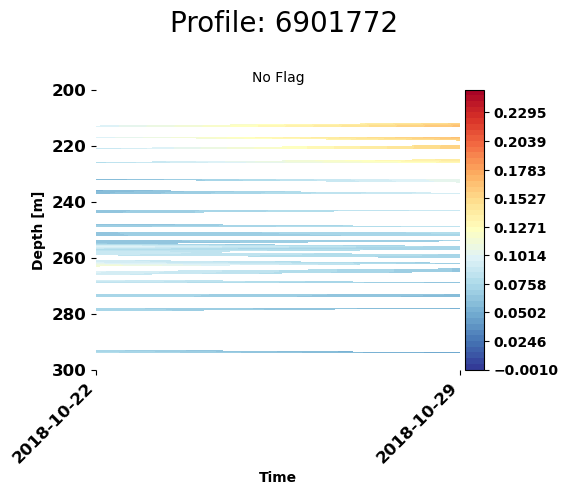

In [32]:
# ===========================================================================================
# Plotting

fig=plt.figure(figsize=(5.,8.))
plt.rcParams["font.weight"]="bold"
plt.rcParams["axes.labelweight"]="bold"

fig.suptitle('Profile: '+station_list[k],fontsize=20)

ax1=subplot(211)
# contourf(np.arange(len(bbp700ixx[:,0])),np.arange(len(bbp700ixx[0,:])),bbp700ixx.T,levels=np.linspace(0,0.05),cmap='RdYlBu_r')
p1=contourf(dates,np.arange(len(chlaixx[0,:])),chlaixx.T,levels=np.linspace(-0.001,0.25),cmap='RdYlBu_r')
ax1.tick_params(axis='x',labelsize=12.,colors='k')
ax1.tick_params(axis='y',labelsize=12.,colors='k')
ax1.invert_yaxis()
ax1.set_title('No Flag',fontsize=10)
ax1.set_ylabel('Depth [m]',fontsize=10)
ax1.set_xlabel('Time',fontsize=10)
ylim(300,200)
akw(ax1)


# Set ticks every ten days
add_colorbar(p1)

# Set ticks every ten days
plt.xticks(dates, rotation=45, ha='right')  # Adjust rotation and alignment as needed

#add_colorbar(p2)

#### ===========================================================================================
## Reference summary for Methods Section, Documentation, or Report
#### ===========================================================================================


- Espino, M., Staneva, J., Alvarez-Fanjul, E., & Sánchez-Arcilla, A. (2022). Editorial: Coastal extension of CMEMS products. Frontiers in Marine Science, 9. https://doi.org/10.3389/fmars.2022.903610 

- Hirshorn, B., Weinstein, S., Wang, D., Koyanagi, K., Becker, N., & McCreery, C. (2021). Earthquake source parameters: Rapid estimates for tsunami forecasts and warnings. In R. A. Meyers (Ed.), Encyclopedia of Complexity and Systems Science (pp. 299–333). Springer. https://doi.org/10.1007/978-1-0716-1705-2_160 

- Copernicus Ocean Science. (2025). Understanding uncertainties in the satellite altimeter measurement of sea level. Ocean Science, 21, 133–150. https://os.copernicus.org/articles/21/133/2025/os-21-133-2025.pdf 

- Bock, N., Cornec, M., Claustre, H., & Duhamel, S. (2022). Biogeographical classification of the global ocean from BGC-Argo floats. Global Biogeochemical Cycles, 36, e2021GB007233. https://doi.org/10.1029/2021GB007233[4](https://agupubs.onlinelibrary.wiley.com/doi/pdf/10.1029/2021GB007233)

- Bittig, H. C., Maurer, T. L., Plant, J. N., Schmechtig, C., Wong, A. P. S., Claustre, H., ... & Xing, X. (2019). A BGC-Argo guide: Planning, deployment, data handling and usage. Frontiers in Marine Science, 6, 502. https://doi.org/10.3389/fmars.2019.00502[5](https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2019.00502/full)

- Johnson, K. S., Plant, J. N., Coletti, L. J., Jannasch, H. W., Sakamoto, C. M., Riser, S. C., & Swift, D. D. (2017). Biogeochemical sensor performance in the SOCCOM profiling float array. Journal of Geophysical Research: Oceans, 122(8), 6416–6436. https://doi.org/10.1002/2017JC012838 1

- Schmechtig, C., Thierry, V., Bittig, H. C., & Claustre, H. (2018). Processing BGC-Argo float data: From decoding to quality control. Frontiers in Marine Science, 5, 6. https://doi.org/10.3389/fmars.2018.00006

- Le Traon, P. Y., Antoine, D., Bentamy, A., Bonekamp, H., Breivik, L. A., Chapron, B., ... & von Schuckmann, K. (2019). The Copernicus Marine Environment Monitoring Service: Main scientific achievements and future prospects. Frontiers in Marine Science, 6, 243. https://doi.org/10.3389/fmars.2019.00243 

- Dibarboure, G., Pujol, M. I., Briol, F., Larnicol, G., Picot, N., Mertz, F., & Ablain, M. (2011). Jason-2 in DUACS: Updated system description, first tandem results and impact on processing and products. Marine Geodesy, 34(3-4), 214–241. https://doi.org/10.1080/01490419.2011.584826 
